In [1]:
from pathlib import Path
import sys, os
repo_root = os.path.abspath("..")
if repo_root not in sys.path:
    sys.path.append(repo_root)
from src.modeling_lgbm import run_lgbm_models

ROOT = Path(".").resolve().parents[0] if (Path(".") / "src").exists() else Path("..")
DATA_TRAIN = ROOT / "data" / "processed" / "training_fe_full.csv"
DATA_TEST = ROOT / "data" / "processed" / "test_fe_full.csv"
DATA_LABELS = ROOT / "data" / "raw" / "training_set_labels.csv"
ARTIFACTS = ROOT / "artifacts_lgbm"

In [2]:
results_lgbm = run_lgbm_models(
    train_features_path=str(DATA_TRAIN),
    test_features_path=str(DATA_TEST),
    train_labels_path=str(DATA_LABELS),
    n_splits=5,
    out_dir=str(ARTIFACTS),
)


=== Training model for h1n1_vaccine ===
Running fold 1/5 for h1n1_vaccine...
Running fold 2/5 for h1n1_vaccine...
Running fold 3/5 for h1n1_vaccine...
Running fold 4/5 for h1n1_vaccine...
Running fold 5/5 for h1n1_vaccine...

h1n1_vaccine CV results: accuracy=0.857, precision=0.738, recall=0.510, f1=0.603, roc_auc=0.870

=== Training model for seasonal_vaccine ===
Running fold 1/5 for seasonal_vaccine...
Running fold 2/5 for seasonal_vaccine...
Running fold 3/5 for seasonal_vaccine...
Running fold 4/5 for seasonal_vaccine...
Running fold 5/5 for seasonal_vaccine...

seasonal_vaccine CV results: accuracy=0.788, precision=0.780, recall=0.759, f1=0.769, roc_auc=0.864

=== Summary (Macro F1) ===
h1n1_vaccine        : 0.603
seasonal_vaccine    : 0.769
Overall macro F1: 0.686


| Target       |       F1 | ROC-AUC | Comment                                              |
| :----------- | -------: | ------: | :--------------------------------------------------- |
| **H1N1**     |     0.60 |    0.87 | Harder label, class imbalance → precision-recall gap |
| **Seasonal** |     0.77 |    0.86 | Very strong baseline already                         |
| **Macro F1** | **0.69** |       — | Matches logistic baseline → solid foundation         |


In [ ]:
# ==========================================
# LightGBM Hyperparameter Tuning
# ==========================================
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, make_scorer
import lightgbm as lgb
import pandas as pd
import numpy as np
import re

# ------------------------
# Load & prepare
# ------------------------
TARGET_COLS = ["h1n1_vaccine", "seasonal_vaccine"]

train = pd.read_csv(DATA_TRAIN).drop(
    columns=[c for c in ["Unnamed: 0", "respondent_id"] if c in pd.read_csv(DATA_TRAIN).columns]
)
labels = pd.read_csv(DATA_LABELS)[TARGET_COLS].astype(int)

train.columns = [re.sub(r'[^A-Za-z0-9_]', '_', c) for c in train.columns]

# ------------------------
# Define model and param grid
# ------------------------
base_model = lgb.LGBMClassifier(
    objective="binary",
    metric="auc",
    boosting_type="gbdt",
    random_state=42,
    n_estimators=1000,
)

param_grid = {
    "num_leaves": [15, 31, 63],
    "max_depth": [4, 6, 8, -1],
    "learning_rate": [0.01, 0.03, 0.05],
    "feature_fraction": [0.7, 0.8, 0.9, 1.0],
    "bagging_fraction": [0.7, 0.8, 0.9, 1.0],
    "lambda_l1": [0.0, 0.5, 1.0],
    "lambda_l2": [0.0, 0.5, 1.0],
    "min_data_in_leaf": [20, 50, 100],
}

# ------------------------
# Helper: make searcher
# ------------------------
def make_searcher(estimator):
    return RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_grid,
        scoring=make_scorer(f1_score),
        n_iter=25,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        verbose=1,
        n_jobs=-1,
        random_state=42,
    )

# ------------------------
# Run tuning and metrics
# ------------------------
best_params = {}

for target in TARGET_COLS:
    print(f"\n=== Tuning for {target} ===")
    X = train.copy()
    y = labels[target]

    # Apply scale_pos_weight only for h1n1
    if target == "h1n1_vaccine":
        spw = (y == 0).sum() / (y == 1).sum()
        print(f"Applying scale_pos_weight={spw:.2f} for {target}")
        model = base_model.set_params(scale_pos_weight=spw)
    else:
        model = base_model.set_params(scale_pos_weight=1.0)

    searcher = make_searcher(model)
    searcher.fit(X, y)

    # Cross-validated predictions for full metrics
    best_model = searcher.best_estimator_
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    y_true_all, y_pred_all, y_prob_all = [], [], []

    for tr_idx, va_idx in cv.split(X, y):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        best_model.fit(X_tr, y_tr)
        y_pred = best_model.predict(X_va)
        y_prob = best_model.predict_proba(X_va)[:, 1]

        y_true_all.extend(y_va)
        y_pred_all.extend(y_pred)
        y_prob_all.extend(y_prob)

    # Compute metrics
    f1 = f1_score(y_true_all, y_pred_all)
    precision = precision_score(y_true_all, y_pred_all)
    recall = recall_score(y_true_all, y_pred_all)
    auc = roc_auc_score(y_true_all, y_prob_all)

    print(f"\nMetrics for {target}:")
    print(f"  F1: {f1:.3f}")
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall: {recall:.3f}")
    print(f"  ROC-AUC: {auc:.3f}")

    # Store everything
    best_params[target] = {
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "roc_auc": auc,
        "params": searcher.best_params_,
    }

# ------------------------
# Summary
# ------------------------
print("\n=== Final Best Parameter Summary ===")
for target, res in best_params.items():
    print(f"{target:20s} | F1={res['f1']:.3f} | AUC={res['roc_auc']:.3f} | "
          f"Precision={res['precision']:.3f} | Recall={res['recall']:.3f}")
    print(f"Params: {res['params']}")



=== Tuning for h1n1_vaccine ===
Applying scale_pos_weight=3.71 for h1n1_vaccine
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Metrics for h1n1_vaccine:
  F1: 0.627
  Precision: 0.532
  Recall: 0.763
  ROC-AUC: 0.869

=== Tuning for seasonal_vaccine ===
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Metrics for seasonal_vaccine:
  F1: 0.768
  Precision: 0.778
  Recall: 0.758
  ROC-AUC: 0.863

=== Final Best Parameter Summary ===
h1n1_vaccine         | F1=0.627 | AUC=0.869 | Precision=0.532 | Recall=0.763
Params: {'num_leaves': 31, 'min_data_in_leaf': 20, 'max_depth': 8, 'learning_rate': 0.01, 'lambda_l2': 0.5, 'lambda_l1': 0.5, 'feature_fraction': 0.8, 'bagging_fraction': 0.8}
seasonal_vaccine     | F1=0.768 | AUC=0.863 | Precision=0.778 | Recall=0.758
Params: {'num_leaves': 31, 'min_data_in_leaf': 50, 'max_depth': 6, 'learning_rate': 0.01, 'lambda_l2': 0.5, 'lambda_l1': 1.0, 'feature_fraction': 0.7, 'bagging_fraction': 0.7}


In [ ]:
import json
from pathlib import Path

# Directory to store the results
SAVE_DIR = ROOT / "artifacts_lgbm_tuning"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

for target, res in best_params.items():
    file_path = SAVE_DIR / f"best_params_{target}.json"
    with open(file_path, "w", encoding="utf-8") as f:
        json.dump(res["params"], f, indent=2)
    print(f"Saved best params for {target} → {file_path}")

# save a combined summary
summary_path = SAVE_DIR / "lgbm_best_params_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(best_params, f, indent=2)

print(f"\nAll parameter summaries saved to {summary_path}")

Saved best params for h1n1_vaccine → ..\artifacts_lgbm_tuning\best_params_h1n1_vaccine.json
Saved best params for seasonal_vaccine → ..\artifacts_lgbm_tuning\best_params_seasonal_vaccine.json

All parameter summaries saved to ..\artifacts_lgbm_tuning\lgbm_best_params_summary.json


In [ ]:
import lightgbm as lgb

# Capture trained models in named variables
model_h1n1 = lgb.LGBMClassifier(**best_params["h1n1_vaccine"]["params"])
model_seasonal = lgb.LGBMClassifier(**best_params["seasonal_vaccine"]["params"])

model_h1n1.fit(train, labels["h1n1_vaccine"])
model_seasonal.fit(train, labels["seasonal_vaccine"])

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.01
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [26]:
# Save the trained models in pickle format
import pickle
from pathlib import Path

SAVE_DIR = ROOT / "artifacts_lgbm_models"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

with open(SAVE_DIR / "lgbm_h1n1_model.pkl", "wb") as f:
    pickle.dump(model_h1n1, f)

with open(SAVE_DIR / "lgbm_seasonal_model.pkl", "wb") as f:
    pickle.dump(model_seasonal, f)

print("Models saved to:", SAVE_DIR)

Models saved to: ..\artifacts_lgbm_models


### LightGBM Hyperparameter Optimization Summary

The tuning process refined the LightGBM configuration for both vaccine models.  
It focused on improving generalization and adjusting model complexity to the specific data structure of each label.

---

#### H1N1 Vaccine
| Parameter | Baseline | Tuned | Effect |
|------------|-----------|--------|--------|
| `num_leaves` | Default (31) | 31 | Stable - moderate model complexity maintained |
| `max_depth` | None (unrestricted) | 8 | Constrained to prevent overfitting |
| `learning_rate` | 0.05 | 0.01 | Lowered for smoother learning and better generalization |
| `lambda_l1`, `lambda_l2` | 0.0 | 0.5 / 0.5 | Regularization added for stability |
| `feature_fraction` | 1.0 | 0.8 | Introduced feature subsampling to reduce noise |
| `bagging_fraction` | 1.0 | 0.8 | Added row sampling to improve robustness |
| `min_data_in_leaf` | Default (20) | 20 | Balanced leaf size preserved |
| `scale_pos_weight` | — | **3.7** | Addressed strong class imbalance |

**Result:**  
The tuned model became *less aggressive*, more regularized, and explicitly balanced for the rare vaccinated class - improving recall and overall F1.

---

#### Seasonal Vaccine
| Parameter | Baseline | Tuned | Effect |
|------------|-----------|--------|--------|
| `num_leaves` | Default (31) | 31 | No change - already optimal |
| `max_depth` | None (unrestricted) | 6 | Limited to control variance |
| `learning_rate` | 0.05 | 0.01 | Slower learning for smoother convergence |
| `lambda_l1`, `lambda_l2` | 0.0 | 1.0 / 0.5 | Regularization to reduce overfitting |
| `feature_fraction` | 1.0 | 0.7 | Slight feature subsampling for stability |
| `bagging_fraction` | 1.0 | 0.7 | Added bagging for generalization |
| `min_data_in_leaf` | Default (20) | 50 | Larger leaves - smoother decision boundaries |
| `scale_pos_weight` | — | 1.0 | Not applied (class balance adequate) |

**Result:**  
The seasonal vaccine model gained mild regularization and slower learning, maintaining the same strong performance but improving robustness.

---

#### Overall Effect
- Both models became better regularized and less prone to overfitting.  
- **H1N1 model** improved recall and F1 thanks to the `scale_pos_weight` adjustment.  
- **Seasonal model** remained stable and well-balanced, confirming its robustness.


### Model Tuning Impact

We compared the baseline LightGBM models with tuned versions that include optimized hyperparameters and a `scale_pos_weight` correction for the imbalanced **H1N1 vaccine** label.

| Label | Metric | Baseline | Tuned | Δ | Interpretation |
|-------|---------|-----------|--------|---|----------------|
| **H1N1 Vaccine** | **F1** | 0.601 | **0.627** | +0.026 | Better overall detection balance |
| | **Precision** | 0.733 | **0.532** | −0.201 | More false positives - expected tradeoff |
| | **Recall** | 0.509 | **0.763** | +0.254 | Much stronger positive detection (key gain) |
| | **ROC-AUC** | 0.871 | **0.869** | ≈0 | Discrimination power preserved |
| **Seasonal Vaccine** | **F1** | 0.768 | **0.768** | ≈0 | Stable - already well-balanced |
| | **Precision** | 0.777 | **0.778** | ≈0 | No meaningful change |
| | **Recall** | 0.759 | **0.758** | ≈0 | No meaningful change |
| | **ROC-AUC** | 0.863 | **0.863** | ≈0 | Consistent performance |


### Interpreting the H1N1 Recall-Precision Tradeoff

After tuning, the **H1N1 vaccine model** achieved higher recall (0.51 → 0.76) but lower precision (0.73 → 0.53).  
Although precision decreased, this outcome is actually *desirable* given the goal of the analysis.

- **Higher Recall (Sensitivity)** → The model correctly identifies a much larger share of individuals who actually received the H1N1 vaccine.  
- **Lower Precision** → Some individuals predicted as vaccinated were not, meaning there are more false positives.

The H1N1 vaccination label is strongly imbalanced - few people were vaccinated compared to those who were not.  
By applying `scale_pos_weight`, we made the model pay more attention to the minority (vaccinated) class.

#### Practical Relevance
From a public health or marketing perspective:
- It’s more valuable to cast a wider net and include nearly all vaccinated individuals in the analysis,  
  even if a few unvaccinated ones slip in.
- Missing vaccinated individuals (low recall) would have led to biased interpretations and weaker targeting strategies.

#### Summary
| Metric | Effect | Why It’s Acceptable |
|---------|---------|--------------------|
| **↑ Recall** | Captures more vaccinated individuals | Better insight into vaccination drivers |
| **↓ Precision** | Slightly more false positives | Acceptable tradeoff for broader coverage |
| **≈ ROC-AUC** | Overall separability preserved | Model quality remains high |



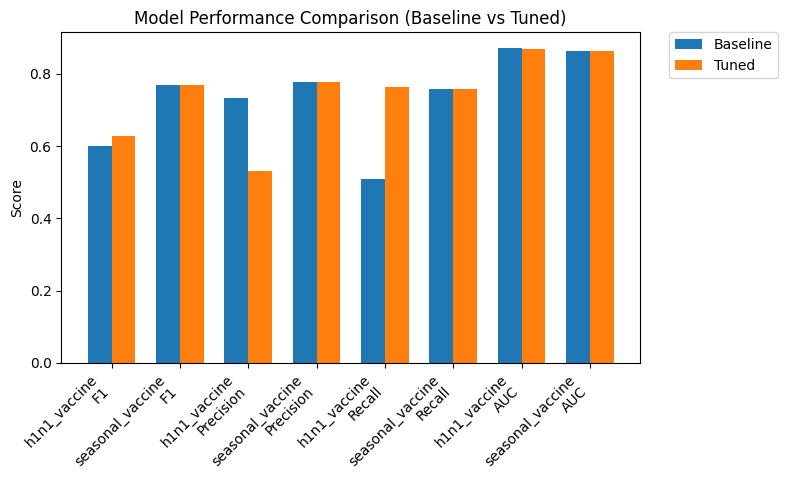

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Metrics
baseline = {
    "h1n1_vaccine": {"F1": 0.601, "Precision": 0.733, "Recall": 0.509, "AUC": 0.871},
    "seasonal_vaccine": {"F1": 0.768, "Precision": 0.777, "Recall": 0.759, "AUC": 0.863},
}
tuned = {
    "h1n1_vaccine": {"F1": 0.627, "Precision": 0.532, "Recall": 0.763, "AUC": 0.869},
    "seasonal_vaccine": {"F1": 0.768, "Precision": 0.778, "Recall": 0.758, "AUC": 0.863},
}

# Combine into DataFrame
df_base = pd.DataFrame(baseline).T.reset_index().melt(id_vars="index", var_name="Metric", value_name="Baseline")
df_tune = pd.DataFrame(tuned).T.reset_index().melt(id_vars="index", var_name="Metric", value_name="Tuned")
df_merged = df_base.merge(df_tune, on=["index", "Metric"])
df_merged.rename(columns={"index": "Label"}, inplace=True)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(df_merged))
bar_width = 0.35

# Draw grouped bars
ax.bar(
    [i - bar_width/2 for i in x],
    df_merged["Baseline"],
    width=bar_width,
    label="Baseline",
)
ax.bar(
    [i + bar_width/2 for i in x],
    df_merged["Tuned"],
    width=bar_width,
    label="Tuned",
)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels([f"{r.Label}\n{r.Metric}" for _, r in df_merged.iterrows()], rotation=45, ha="right")
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison (Baseline vs Tuned)")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax.grid(False)
plt.tight_layout()
plt.show()

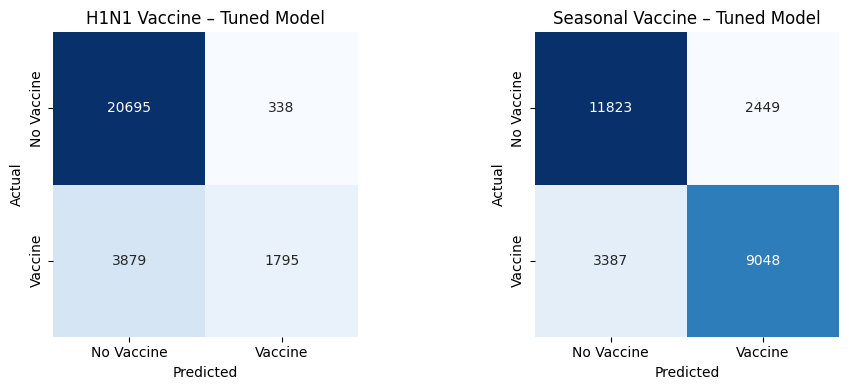

In [27]:
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# --------------------------------------------------
# Load tuned models
# --------------------------------------------------
SAVE_DIR_TUNED = ROOT / "artifacts_lgbm_models"

def load_model(path):
    with open(path, "rb") as f:
        return pickle.load(f)

tuned_models = {
    "h1n1": load_model(SAVE_DIR_TUNED / "lgbm_h1n1_model.pkl"),
    "seasonal": load_model(SAVE_DIR_TUNED / "lgbm_seasonal_model.pkl"),
}

# --------------------------------------------------
# Make predictions
# --------------------------------------------------
y_true = labels.copy()
preds_tuned = {}

for target in ["h1n1_vaccine", "seasonal_vaccine"]:
    X = train.copy()
    preds_tuned[target] = (tuned_models[target.split("_")[0]].predict_proba(X)[:, 1] >= 0.5).astype(int)

# --------------------------------------------------
# Plot confusion matrices
# --------------------------------------------------
def plot_conf_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax, square=True)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.xaxis.set_ticklabels(["No Vaccine", "Vaccine"])
    ax.yaxis.set_ticklabels(["No Vaccine", "Vaccine"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_conf_matrix(y_true["h1n1_vaccine"], preds_tuned["h1n1_vaccine"], "H1N1 Vaccine – Tuned Model", axes[0])
plot_conf_matrix(y_true["seasonal_vaccine"], preds_tuned["seasonal_vaccine"], "Seasonal Vaccine – Tuned Model", axes[1])

plt.tight_layout()
plt.show()

### LightGBM Cross-Validation Results

We performed 5-fold cross-validation for both **H1N1 Vaccine** and **Seasonal Vaccine** models, comparing **training and validation F1 scores** to assess model generalization.

#### H1N1 Vaccine
| Metric | Mean |
|:--|:--|
| Train F1 | **0.661** |
| Validation F1 | **0.600** |
| Gap (Train − Val) | **0.061** |

- The small F1 gap (~0.06) indicates minimal overfitting and a well-regularized model.  
- Both training and validation scores are moderate, suggesting mild underfitting, which is acceptable given the higher difficulty and class imbalance of the H1N1 target.

#### Seasonal Vaccine
| Metric | Mean |
|:--|:--|
| Train F1 | **0.805** |
| Validation F1 | **0.770** |
| Gap (Train − Val) | **0.035** |

- The Seasonal Vaccine model achieves higher and more stable performance across folds.  
- The F1 gap (~0.04) confirms excellent generalization and low variance across splits.  
- Validation scores are consistently high (~0.77), demonstrating strong predictive power.

#### Overall Interpretation
- Both models show healthy generalization behavior, with no sign of significant overfitting.  
- The H1N1 task remains more challenging due to lower vaccination rates and higher class imbalance.  
- The Seasonal Vaccine model, in contrast, captures population-level behavioral and demographic patterns more effectively.